<a href="https://colab.research.google.com/github/miriam-silva/ProvaIcomaAM/blob/main/prova_01_miriam_silva.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pipeline 1 | Extração e Carregamento de Dados [Fase 1]

## Bibliotecas Python

In [53]:
import requests
import pandas as pd

## Consumo da API (Alpha Vantage)

In [54]:
API_KEY = '4UAUPZP06FCMODZI'
url = f'https://www.alphavantage.co/query?function=TIME_SERIES_DAILY&symbol=IBM&apikey={API_KEY}&outputsize=compact'
response = requests.get(url)
data = response.json()

## Transformação para DataFrame

In [55]:
df = pd.DataFrame.from_dict(data['Time Series (Daily)'], orient='index')
df.columns = ['open', 'high', 'low', 'close', 'volume']
df = df.astype(float)
df.index = pd.to_datetime(df.index)
df = df.sort_index()

In [56]:
df.head()

,open,high,low,close,volume
2025-12-08,309.62,315.3454,307.9500,309.18,3615794.0
2025-12-09,309.63,313.9700,308.7500,310.48,2914275.0
2025-12-10,310.23,314.6900,306.6513,312.67,3411524.0
2025-12-11,312.00,313.4400,308.4000,310.74,2755749.0
2025-12-12,310.57,311.0500,303.3300,309.24,2953374.0


# Pipeline 2 | Tratamento e Normalização [Fase 2]

## Bibliotecas

In [57]:
import numpy as np
from sklearn.preprocessing import StandardScaler

## Verificação de valores nulos

In [58]:
df.isnull().sum()

,0
open,0
high,0
low,0
close,0
volume,0


## Conversão de tipos (apenas dados numéricos)

In [59]:
df = df.astype(float)

## Tratamento de assimetria (volume)

In [60]:
df['volume_log'] = np.log1p(df['volume'])

## Separação de variáveis preditoras (X)

In [61]:
X = df[['open', 'high', 'low', 'close', 'volume_log']]

## Normalização dos dados (StandardScaler)

In [62]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Pipeline 3 | Visualização de Dados [Fase 3]

## Bibliotecas para visualização

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns

## Visualização inicial dos dados

In [64]:
df.head()

,open,high,low,close,volume,volume_log
2025-12-08,309.62,315.3454,307.9500,309.18,3615794.0,15.100822
2025-12-09,309.63,313.9700,308.7500,310.48,2914275.0,14.885132
2025-12-10,310.23,314.6900,306.6513,312.67,3411524.0,15.042670
2025-12-11,312.00,313.4400,308.4000,310.74,2755749.0,14.829200
2025-12-12,310.57,311.0500,303.3300,309.24,2953374.0,14.898459


## Verificação de valores únicos

In [65]:
df['volume'].nunique()

100

## Gráfico de fechamento

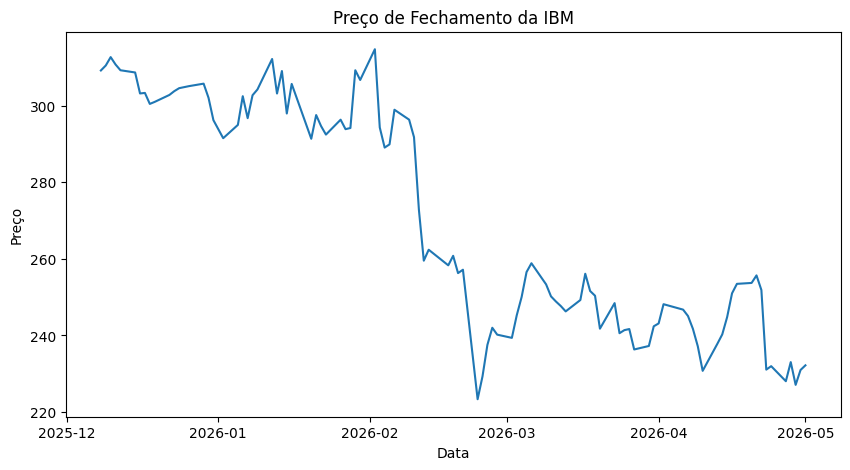

In [66]:
plt.figure(figsize=(10,5))
plt.plot(df['close'])

plt.title('Preço de Fechamento da IBM')
plt.xlabel('Data')
plt.ylabel('Preço')
plt.show()

## Histograma de fechamento

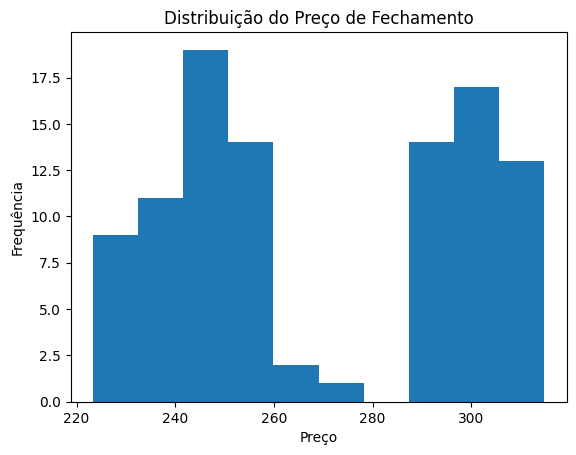

In [67]:
plt.hist(df['close'], bins=10)

plt.title('Distribuição do Preço de Fechamento')
plt.xlabel('Preço')
plt.ylabel('Frequência')
plt.show()

## Histograma do volume

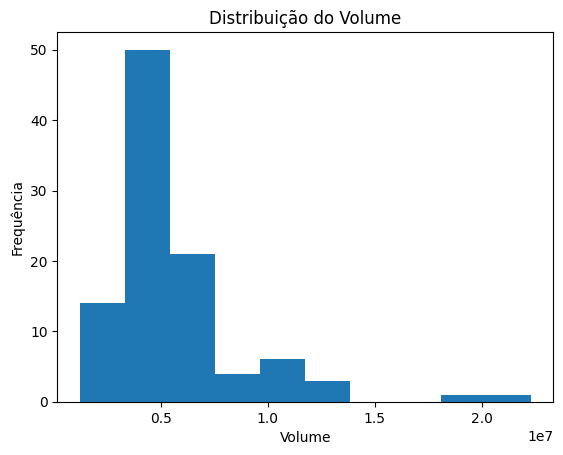

In [68]:
plt.hist(df['volume'], bins=10)

plt.title('Distribuição do Volume')
plt.xlabel('Volume')
plt.ylabel('Frequência')
plt.show()

## Histograma do volume tratado

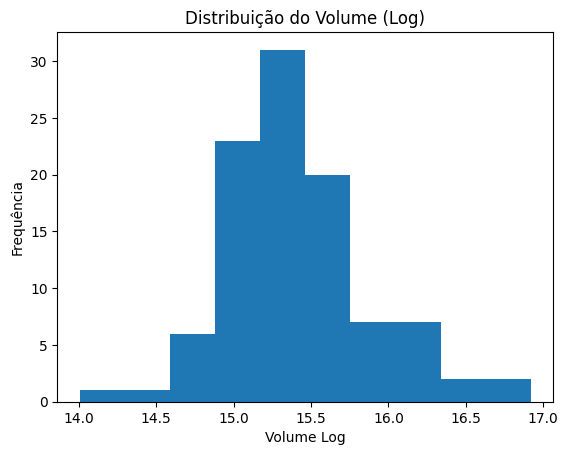

In [69]:
plt.hist(df['volume_log'], bins=10)

plt.title('Distribuição do Volume (Log)')
plt.xlabel('Volume Log')
plt.ylabel('Frequência')
plt.show()

# Pipeline 4 | Laborização [Fase 4]

## Criação da variável alvo (target)

In [70]:
df['target'] = (df['close'] > df['open']).astype(int)

## Verificação da variável alvo criada

In [71]:
df[['open', 'close', 'target']].head()

,open,close,target
2025-12-08,309.62,309.18,0
2025-12-09,309.63,310.48,1
2025-12-10,310.23,312.67,1
2025-12-11,312.00,310.74,0
2025-12-12,310.57,309.24,0


## Separação das variáveis preditoras (X) e variável alvo (Y)

In [72]:
X = X_scaled
y = df['target']

# Pipeline 5 | Ingestão Bayesiana [Fase 5]

## Bibliotecas para modelagem

In [73]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

## Divisão dos dados em treino e teste

In [74]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Criação do modelo Naive Bayes Gaussiano

In [75]:
modelo = GaussianNB()

## Treinamento do modelo

In [76]:
modelo.fit(X_train, y_train)

GaussianNB()

## Realização das previsões

In [77]:
y_pred = modelo.predict(X_test)

## Avaliação do modelo (acurácia)

In [78]:
acuracia = accuracy_score(y_test, y_pred)

In [81]:
print("Acurácia do modelo:", acuracia)

Acurácia do modelo: 0.6
